In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from scipy.fft import fft2, ifft2, ifftshift

### Task#1: Filtering in the Frequency Domain

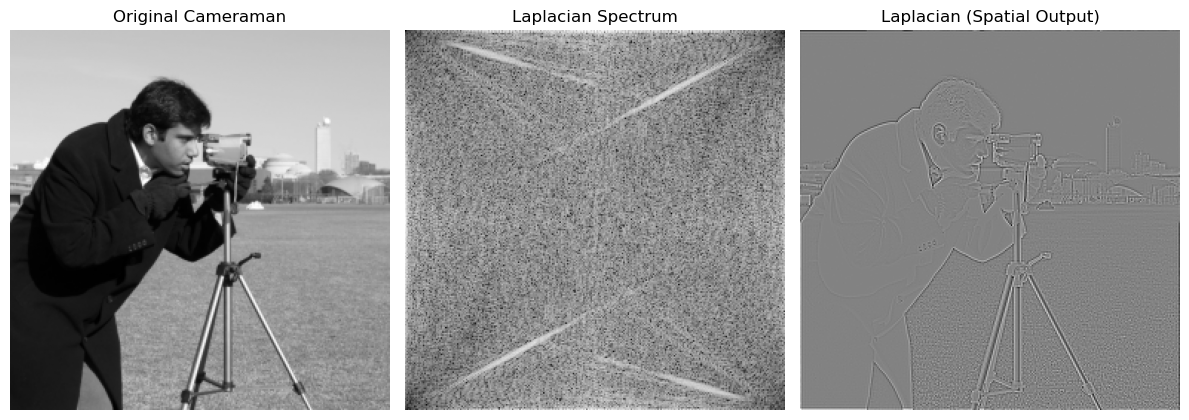

In [27]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256)) # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')
plt.tight_layout()
plt.show()

#### The student will be asked to accomplish the following tasks within the lab time.
### Task#1: Using the same Cameraman image, apply the Sobel filter(s) in the frequency domain and show the results.

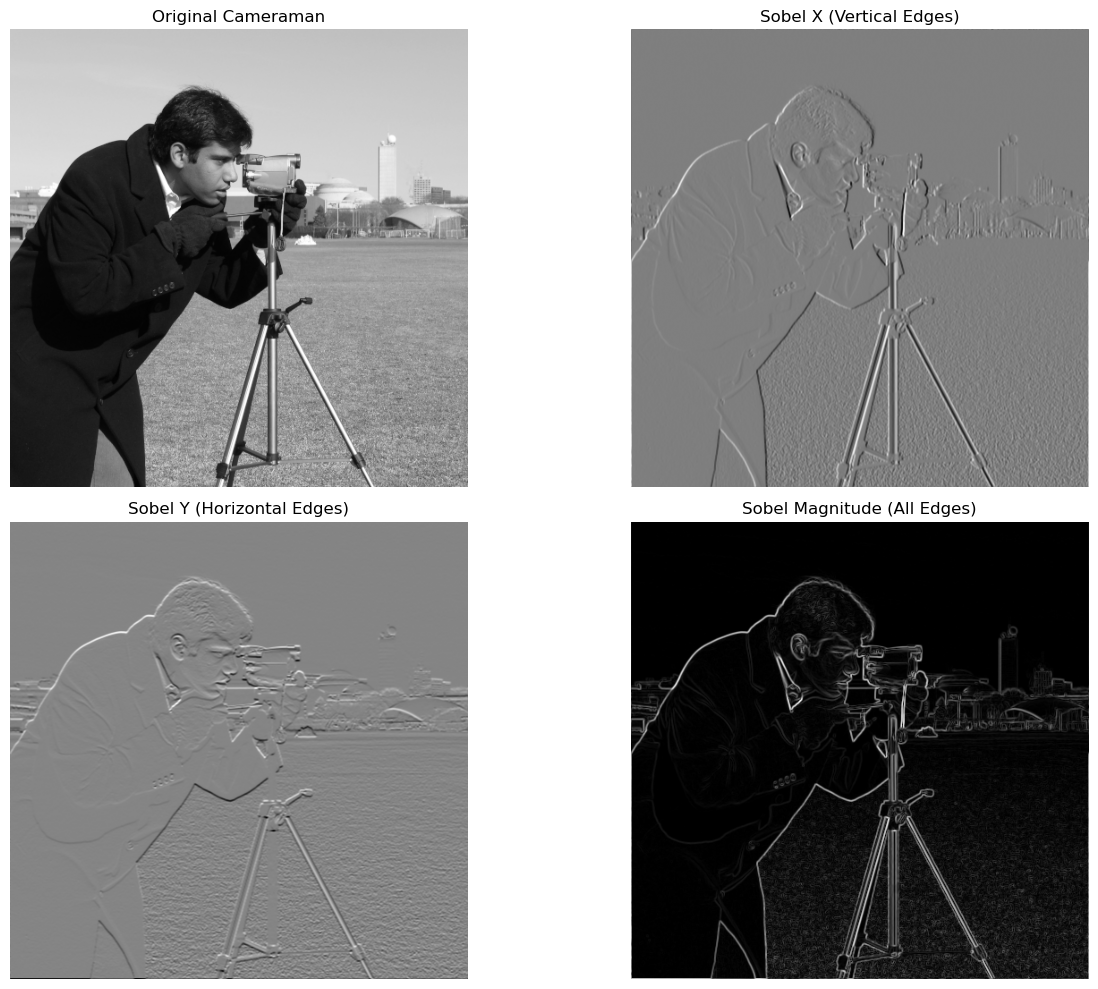

In [22]:
# Load and resize image (using the standard skimage cameraman)
img = data.camera()
img = img / 255.0

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    
    # Shift before FFT to place (0,0) at top-left
    return fft2(ifftshift(padded)) 

# Compute FFT of image
F = fft2(img)

# FFT of centered Sobel filters (use the provided function)
Hx = center_embed_kernel(sobel_x, img.shape)
Hy = center_embed_kernel(sobel_y, img.shape)

Gx = F * Hx
Gy = F * Hy

gx = np.real(ifft2(Gx))
gy = np.real(ifft2(Gy))

gx_norm = (gx - gx.min()) / (gx.max() - gx.min())
gy_norm = (gy - gy.min()) / (gy.max() - gy.min())

magnitude = np.sqrt(gx**2 + gy**2)
magnitude_norm = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

# Plot
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Cameraman")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gx_norm, cmap='gray')
plt.title("Sobel X (Vertical Edges)")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gy_norm, cmap='gray')
plt.title("Sobel Y (Horizontal Edges)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(magnitude_norm, cmap='gray')
plt.title("Sobel Magnitude (All Edges)")
plt.axis('off')

plt.tight_layout()
plt.show()